In [ ]:
# %% [Cell 1] 대규모 파생 변수(Feature Engineering) 생성 및 정합성 확보
import pandas as pd
import numpy as np

print("[Step 1] 대규모 파생 변수(Feature Engineering) 생성 시작")

# 1. 절대 경로 데이터 로드 및 엄격한 결측치 정제
file_path = r"C:\dev\SKN27-2nd-1TEAM\00_data\Telco_customer_churn - Telco_Churn.csv"
df = pd.read_csv(file_path)

# [수정] Total Charges 빈칸을 NaN 처리 후, 결측치(Tenure 0인 신규가입자) 행 완전 삭제
df['Total Charges'] = pd.to_numeric(df['Total Charges'].replace(' ', np.nan))
df.dropna(subset=['Total Charges'], inplace=True)

df['Churn Value'] = df['Churn Value'].astype(int)

# 2. 서비스 카운트 기반 변수 (밀집도) - [수정] apply 제거 및 Vectorized 연산으로 속도 최적화
internet_services = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
df['Total_Internet_Services'] = (df[internet_services] == 'Yes').sum(axis=1)
df['Total_Streaming'] = (df[['Streaming TV', 'Streaming Movies']] == 'Yes').sum(axis=1)
df['Total_Security'] = (df[['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']] == 'Yes').sum(axis=1)

# 3. 요금(Financial) 기반 연속형 비율 변수
df['Extra_Charges'] = df['Total Charges'] - (df['Monthly Charges'] * df['Tenure Months'])
df['Price_per_Service'] = df['Monthly Charges'] / (df['Total_Internet_Services'] + 1)
df['Total_to_Monthly_Ratio'] = df['Total Charges'] / (df['Monthly Charges'] + 1e-5)
df['Tenure_to_Monthly_Ratio'] = df['Tenure Months'] / (df['Monthly Charges'] + 1e-5)
df['Monthly_to_Median_Ratio'] = df['Monthly Charges'] / df['Monthly Charges'].median()

# 4. 그룹 통계 기반 변수 (집단 내 고객의 요금/유지기간 상대적 위치)
df['Avg_Monthly_by_Contract'] = df.groupby('Contract')['Monthly Charges'].transform('mean')
df['Diff_from_Contract_Monthly'] = df['Monthly Charges'] - df['Avg_Monthly_by_Contract']
df['Avg_Tenure_by_Contract'] = df.groupby('Contract')['Tenure Months'].transform('mean')
df['Diff_from_Contract_Tenure'] = df['Tenure Months'] - df['Avg_Tenure_by_Contract']

# 5. 고객 인구통계 및 관계 기반 이진 변수
df['Is_Full_Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)
df['Is_Single_Senior'] = ((df['Senior Citizen'] == 1) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)
df['Is_Independent_Youth'] = ((df['Senior Citizen'] == 0) & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)

# 6. 행동 및 가입 특성 기반 지표
df['Is_New_Customer'] = (df['Tenure Months'] <= 6).astype(int)
df['Is_Long_Term_Customer'] = (df['Tenure Months'] >= 60).astype(int)
df['Has_Internet_But_No_Service'] = ((df['Internet Service'] != 'No') & (df['Total_Internet_Services'] == 0)).astype(int)
df['Has_All_Services'] = (df['Total_Internet_Services'] == 6).astype(int)
df['Is_Auto_Payment'] = df['Payment Method'].astype(str).str.contains('automatic', case=False).astype(int)

# 7. 복합 가설 기반 이탈 위험군 (High Risk Flags)
df['Risk_Fiber_MtM'] = ((df['Internet Service'] == 'Fiber optic') & (df['Contract'] == 'Month-to-month')).astype(int)
df['Risk_Payment_Friction'] = ((df['Payment Method'] == 'Electronic check') & (df['Paperless Billing'] == 'Yes')).astype(int)
df['Risk_High_Charge_MtM'] = ((df['Contract'] == 'Month-to-month') & (df['Monthly Charges'] > df['Monthly Charges'].median())).astype(int)
df['Risk_No_TechSupport_Fiber'] = ((df['Internet Service'] == 'Fiber optic') & (df['Tech Support'] == 'No')).astype(int)

# 8. 비선형(다항) 파생 변수
df['Tenure_Sq'] = df['Tenure Months'] ** 2
df['Monthly_Charges_Sq'] = df['Monthly Charges'] ** 2
df['Tenure_x_Monthly'] = df['Tenure Months'] * df['Monthly Charges']

print(f"결과: 대규모 파생 변수 세팅 완료. 최종 데이터 형상: {df.shape}")

[Step 1] 대규모 파생 변수(Feature Engineering) 생성 시작
결과: 대규모 파생 변수 세팅 완료. 최종 데이터 형상: (7032, 60)


In [14]:
# %% [Cell 2] 데이터 분할, 네이티브 타겟 인코딩 및 전체 통합 스케일링
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder

print("[Step 2] 데이터 분할, 네이티브 타겟 인코딩 및 전체 데이터 통합 스케일링 시작")

# 1. 타겟 누수(Data Leakage) 및 무의미한 식별자 컬럼 차단
leakage_and_useless_cols = [
    'Churn Reason', 'Churn Label', 'CustomerID', 
    'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Lat Long', 'Churn Score'
]
cols_to_drop = [col for col in leakage_and_useless_cols if col in df.columns]

X = df.drop(columns=cols_to_drop + ['Churn Value'])
y = df['Churn Value']

# 2. 누수 방지를 위한 훈련/테스트 선 분할 (층화 추출)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"생성된 총 피처(Feature) 개수: {X_train.shape[1]}개")

# 3. 범주형 데이터 변환 (Scikit-learn 네이티브 ColumnTransformer 활용)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# ColumnTransformer를 통해 범주형 컬럼만 타겟 인코딩하고, 나머지는 그대로 통과(passthrough)
encoder_pipeline = ColumnTransformer(
    transformers=[
        # 내장 TargetEncoder는 내부 교차 검증으로 과적합을 자동 방어합니다.
        ('target_enc', TargetEncoder(smooth="auto"), cat_cols) 
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# 인코딩 수행 및 DataFrame 복원 (Feature name 유지)
X_train_encoded = pd.DataFrame(
    encoder_pipeline.fit_transform(X_train, y_train), 
    columns=encoder_pipeline.get_feature_names_out(), 
    index=X_train.index
)
X_test_encoded = pd.DataFrame(
    encoder_pipeline.transform(X_test), 
    columns=encoder_pipeline.get_feature_names_out(), 
    index=X_test.index
)

# 4. 전체 데이터 표준화(Standard Scaling)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test.index)

print(f"결과: Scikit-learn 네이티브 타겟 인코딩 및 전면 스케일링 완료. 최종 학습 데이터 형상: {X_train_scaled.shape}")

[Step 2] 데이터 분할, 네이티브 타겟 인코딩 및 전체 데이터 통합 스케일링 시작
생성된 총 피처(Feature) 개수: 47개
결과: Scikit-learn 네이티브 타겟 인코딩 및 전면 스케일링 완료. 최종 학습 데이터 형상: (5625, 47)


In [15]:
# %% [Cell 3] 40+ 피처 기반 스태킹 모델 학습 및 평가
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("[Step 3] 40+ 피처 기반 스태킹 모델 학습 시작 (엄격한 규제 및 편향 제어 적용)")

# 1. 클래스 불균형 비율 산출
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 2. 베이스 모델 정의 (과적합 방어 및 불균형 제어)
# [수정] 최신 XGBoost 버전에서 에러를 유발하는 use_label_encoder 파라미터 완전 삭제
lgbm = LGBMClassifier(random_state=42, n_estimators=300, learning_rate=0.03, colsample_bytree=0.7, subsample=0.7, class_weight='balanced', verbose=-1)
xgb = XGBClassifier(random_state=42, n_estimators=300, learning_rate=0.03, colsample_bytree=0.7, subsample=0.7, scale_pos_weight=ratio, eval_metric='logloss')
cat = CatBoostClassifier(random_state=42, iterations=300, learning_rate=0.03, depth=5, auto_class_weights='Balanced', verbose=0)

estimators = [('lgbm', lgbm), ('xgb', xgb), ('cat', cat)]

# 3. 메타 모델 최적화
# [수정] 이중 가중치 편향(Double Weighting Bias)을 수학적으로 차단하기 위해 메타 모델의 class_weight 파라미터 삭제
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=0.05, max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

# 4. 학습 및 평가 (새로 생성된 X_train_scaled, X_test_scaled 사용)
stacking_model.fit(X_train_scaled, y_train)

y_pred = stacking_model.predict(X_test_scaled)
y_pred_proba = stacking_model.predict_proba(X_test_scaled)[:, 1]

print("\n[최종 40+ 피처 스태킹 모델 성능 지표]")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred))

[Step 3] 40+ 피처 기반 스태킹 모델 학습 시작 (엄격한 규제 및 편향 제어 적용)

[최종 40+ 피처 스태킹 모델 성능 지표]
Accuracy : 0.7967
AUC Score : 0.8498
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1033
           1       0.62      0.61      0.61       374

    accuracy                           0.80      1407
   macro avg       0.74      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



[Step 4] 대규모 피처 적용 모델의 최적 임계값 탐색 시작
산출 완료: 새로운 최적 임계값 = 0.4109


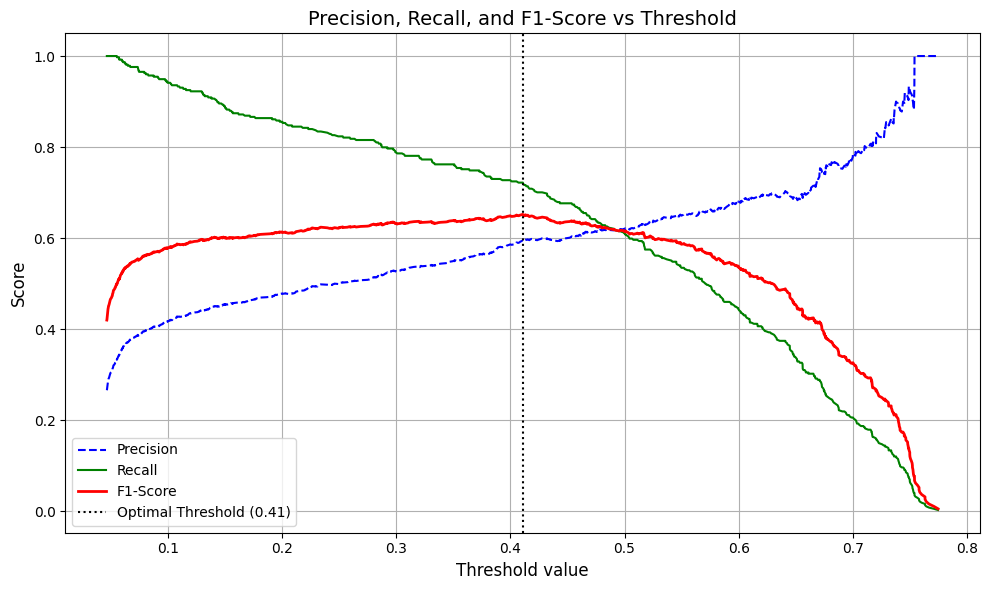


[임계값 조정 성능 비교]
기존 Accuracy (Threshold 0.5) : 0.7967
최적 Accuracy (Threshold 0.4109) : 0.7953
--------------------------------------------------
=== Classification Report (최적 임계값 적용) ===
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1033
           1       0.59      0.72      0.65       374

    accuracy                           0.80      1407
   macro avg       0.74      0.77      0.75      1407
weighted avg       0.81      0.80      0.80      1407



In [16]:
# %% [Cell 4] 대규모 피처 적용 모델의 최적 임계값 탐색 및 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report

print("[Step 4] 대규모 피처 적용 모델의 최적 임계값 탐색 시작")

# 1. 테스트 데이터에 대한 예측 확률 추출
y_pred_proba_final = stacking_model.predict_proba(X_test_scaled)[:, 1]

# 2. 정밀도, 재현율, 임계값 산출
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_final)

# [수정] 배열 길이 불일치(Out of Bounds) 에러를 방어하기 위한 슬라이싱 적용
# precisions와 recalls는 thresholds보다 길이가 1개 더 긺
precisions_adj = precisions[:-1]
recalls_adj = recalls[:-1]

# 3. F1-Score 극대화 지점 탐색
f1_scores = 2 * (precisions_adj * recalls_adj) / (precisions_adj + recalls_adj + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"산출 완료: 새로운 최적 임계값 = {optimal_threshold:.4f}")

# 4. 분석가를 위한 시각적 검증 통제망 구축 (PR 곡선 및 Threshold 추세)
plt.figure(figsize=(10, 6))
plt.title("Precision, Recall, and F1-Score vs Threshold", fontsize=14)
plt.plot(thresholds, precisions_adj, 'b--', label='Precision')
plt.plot(thresholds, recalls_adj, 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, label='F1-Score')

# 최적 임계값 수직선 마킹
plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel("Threshold value", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. 임계값 적용 후 성능 비교
# 이전 셀에서 생성된 y_pred를 재활용하지 않고 안전하게 다시 생성 (변수 꼬임 방지)
y_pred_default = (y_pred_proba_final >= 0.5).astype(int)
y_pred_optimal = (y_pred_proba_final >= optimal_threshold).astype(int)

print("\n[임계값 조정 성능 비교]")
print(f"기존 Accuracy (Threshold 0.5) : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"최적 Accuracy (Threshold {optimal_threshold:.4f}) : {accuracy_score(y_test, y_pred_optimal):.4f}")
print("-" * 50)
print("=== Classification Report (최적 임계값 적용) ===")
print(classification_report(y_test, y_pred_optimal))

In [17]:
# %% [Cell 5] 40+ 피처 모델 전체 데이터 재학습 및 객체 추출 (엄격한 통제 적용)
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder

print("[Step 5] 40+ 피처 모델 전체 데이터 재학습 및 객체 추출 시작")

# 1. 40+ 피처가 포함된 전체 데이터(df)에서 누수 피처 및 정답 분리
leakage_and_useless_cols = [
    'Churn Reason', 'Churn Label', 'CustomerID', 
    'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Lat Long', 'Churn Score'
]
cols_to_drop = [col for col in leakage_and_useless_cols if col in df.columns]

X_final = df.drop(columns=cols_to_drop + ['Churn Value'])
y_final = df['Churn Value']

# 2. 전체 데이터 네이티브 타겟 인코딩 (Scikit-learn ColumnTransformer 활용)
cat_cols = X_final.select_dtypes(include=['object', 'category']).columns.tolist()

final_encoder_pipeline = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(smooth="auto"), cat_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_final_encoded = pd.DataFrame(
    final_encoder_pipeline.fit_transform(X_final, y_final), 
    columns=final_encoder_pipeline.get_feature_names_out(), 
    index=X_final.index
)

# 3. 전체 데이터 스케일링
final_scaler = StandardScaler()
X_final_scaled = pd.DataFrame(
    final_scaler.fit_transform(X_final_encoded), 
    columns=X_final_encoded.columns, 
    index=X_final.index
)

# 4. 모델 재정의 및 학습 (이중 가중치 및 구버전 파라미터 완전 차단)
ratio_final = float(np.sum(y_final == 0)) / np.sum(y_final == 1)

lgbm_final = LGBMClassifier(random_state=42, n_estimators=300, learning_rate=0.03, colsample_bytree=0.7, subsample=0.7, class_weight='balanced', verbose=-1)
xgb_final = XGBClassifier(random_state=42, n_estimators=300, learning_rate=0.03, colsample_bytree=0.7, subsample=0.7, scale_pos_weight=ratio_final, eval_metric='logloss')
cat_final = CatBoostClassifier(random_state=42, iterations=300, learning_rate=0.03, depth=5, auto_class_weights='Balanced', verbose=0)

estimators_final = [('lgbm', lgbm_final), ('xgb', xgb_final), ('cat', cat_final)]

# [수정] 메타 모델의 class_weight 제거, StratifiedKFold 적용
final_model = StackingClassifier(
    estimators=estimators_final,
    final_estimator=LogisticRegression(C=0.05, max_iter=1000), 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

print("전체 데이터를 활용한 40+ 피처 스태킹 모델 최종 학습 진행 중...")
final_model.fit(X_final_scaled, y_final)

# 5. 프론트엔드 연동을 위한 파일 안전한 직렬화 (Serialization)
save_dir = r"C:\dev\SKN27-2nd-1TEAM\03_saved_models"  # 경로 철자 교정 (프로젝트 폴더명)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

joblib.dump(final_model, os.path.join(save_dir, 'churn_stacking_model.pkl'))
joblib.dump(final_encoder_pipeline, os.path.join(save_dir, 'target_encoder.pkl')) # 교정된 파이프라인 객체 저장
joblib.dump(final_scaler, os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(X_final.columns.tolist(), os.path.join(save_dir, 'model_columns.pkl'))

# [추가] 프론트엔드에서 활용할 수 있도록 Step 4에서 구한 최적 임계값(Optimal Threshold)도 함께 저장
joblib.dump(optimal_threshold, os.path.join(save_dir, 'optimal_threshold.pkl'))

print(f"결과: 모든 모델 파라미터 및 전처리 객체가 [{save_dir}] 경로에 무결하게 직렬화되었습니다.")

[Step 5] 40+ 피처 모델 전체 데이터 재학습 및 객체 추출 시작
전체 데이터를 활용한 40+ 피처 스태킹 모델 최종 학습 진행 중...
결과: 모든 모델 파라미터 및 전처리 객체가 [C:\dev\SKN27-2nd-1TEAM\03_saved_models] 경로에 무결하게 직렬화되었습니다.
